In [7]:
#imports
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import re
import json
import joblib
from collections import Counter, defaultdict


from scipy.signal import welch
from scipy.stats import kurtosis, skew
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit, LeaveOneGroupOut
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay, accuracy_score


import pyxdf

In [8]:
DATA_FOLDER = Path("/Users/janniella/Desktop/Mirage/prototype")
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_CHANNELS = ["F3", "F4", "C3", "Cz", "C4", "P3", "P4"]

RUN_MARKER_TO_LABEL = {
    "rest": 0,
    "blinking": 1,
    "teeth_clenching": 2,
}

LABEL_TO_NAME = {
    0: "neutral",
    1: "blink",
    2: "clench",
}

BANDPASS_LOW = 0.5
BANDPASS_HIGH = 100.0
USE_NOTCH = True
NOTCH_FREQ = 50.0 #elektrizität

WINDOW_SEC = 0.5
STEP_SEC = 0.1

TEST_SIZE = 0.2
RANDOM_STATE = 42
MIN_SEGMENT_SEC = 0.5 


XDF_GLOB = "*.xdf"

In [9]:
#Hilfsfunktionen, extrahiert 
def parse_subject_id(filename):
    stem = Path(filename).stem.lower()
    match = re.search(r"_p(\d+)", stem)
    if match:
        return f"p{match.group(1)}"
    return stem


def safe_marker_name(value):
    """Normalize marker values from XDF."""
    if isinstance(value, (list, tuple, np.ndarray)):
        if len(value) == 0:
            return ""
        value = value[0]
    return str(value).strip()


def print_marker_timeline(markers_df, max_rows=20):
    """Quick human-readable preview of markers."""
    if markers_df is None or markers_df.empty:
        print("No markers found.")
        return

    preview = markers_df.head(max_rows)
    for _, row in preview.iterrows():
        print(f'Marker "{row["marker"]}" @ {row["timestamp"]:.2f}s '
              f'(rel_eeg={row["time_from_eeg_start_sec"]:.2f}s)')

In [10]:
#ladet xdf files
def load_xdf_run(xdf_file, target_channels=None):
    
    streams, header = pyxdf.load_xdf(str(xdf_file))

    eeg_stream = None
    marker_stream = None

    for s in streams:
        name = s["info"].get("name", [""])[0]
        stype = s["info"].get("type", [""])[0]

        if stype.upper() == "EEG" and eeg_stream is None:
            eeg_stream = s

        if stype.lower() == "markers" or name.lower() == "paradigm":
            marker_stream = s

    if eeg_stream is None:
        raise ValueError(f"No EEG stream found in {xdf_file}")

    # EEG data
    eeg_data = np.asarray(eeg_stream["time_series"], dtype=float)  
    eeg_timestamps = np.asarray(eeg_stream["time_stamps"], dtype=float)
    sfreq = float(eeg_stream["info"]["nominal_srate"][0])


    ch_info = eeg_stream["info"]["desc"][0]["channels"][0]["channel"]
    ch_names = [ch["label"][0] for ch in ch_info]

    #xdf speichert als samplexchannels aber MNE möchte channels x samples
    eeg_data = eeg_data.T

    #nur die channels die genutzt werden
    if target_channels is not None:
        picks = [i for i, ch in enumerate(ch_names) if ch in target_channels]
        picked_names = [ch_names[i] for i in picks]

        if len(picks) == 0:
            raise ValueError(f"No target channels found in {xdf_file}")

        eeg_data = eeg_data[picks, :]
        ch_names = picked_names

        
        missing = [ch for ch in target_channels if ch not in ch_names]
        if missing:
            print(f"Warning: {Path(xdf_file).name} missing channels: {missing}")

        present_order = [ch for ch in target_channels if ch in ch_names]
        reorder_idx = [ch_names.index(ch) for ch in present_order]
        eeg_data = eeg_data[reorder_idx, :]
        ch_names = [ch_names[i] for i in reorder_idx]

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
    raw = mne.io.RawArray(eeg_data, info, verbose=False)

    #Marker zu pd DF
    markers_df = None
    if marker_stream is not None:
        marker_timestamps = np.asarray(marker_stream["time_stamps"], dtype=float)
        marker_values = [safe_marker_name(v) for v in marker_stream["time_series"]]

        eeg_start_ts = eeg_timestamps[0]
        markers_df = pd.DataFrame({
            "timestamp": marker_timestamps,
            "marker": marker_values,
            "time_from_eeg_start_sec": marker_timestamps - eeg_start_ts,
        })

    subject_name = Path(xdf_file).stem
    group_id = parse_subject_id(xdf_file)

    return subject_name, raw, markers_df, group_id


def load_all_xdf_runs(data_folder, target_channels=None, pattern="*.xdf"):
    runs = []
    files = sorted(glob(str(Path(data_folder) / pattern)))
    print(f"Found {len(files)} XDF file(s).")

    for file in files:
        subject_name, raw, markers_df, group_id = load_xdf_run(
            file,
            target_channels=target_channels
        )

        run_info = {
            "subject_name": subject_name,
            "group_id": group_id,
            "raw": raw,
            "markers": markers_df,
            "file_path": file,
        }
        runs.append(run_info)

        print(f"\nLoaded: {subject_name}")
        print(f"Group ID: {group_id}")
        print("Channels:", raw.ch_names)
        if markers_df is not None:
            print("Unique markers:", sorted(markers_df["marker"].unique()))
        else:
            print("No marker stream found.")

    return runs

In [11]:
runs = load_all_xdf_runs(DATA_FOLDER, target_channels=TARGET_CHANNELS, pattern=XDF_GLOB)
print(f"Total runs loaded: {len(runs)}")

example_run = runs[0]
print("Example run:", example_run["subject_name"])
print_marker_timeline(example_run["markers"], max_rows=30)

Found 3 XDF file(s).

Loaded: run1_p1
Group ID: p1
Channels: ['F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'P4']
Unique markers: ['blinking', 'pause', 'pre_cue', 'rest', 'teeth_clenching']

Loaded: run1_p2
Group ID: p2
Channels: ['F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'P4']
Unique markers: ['blinking', 'pause', 'pre_cue', 'rest', 'teeth_clenching']

Loaded: run2_p1
Group ID: p1
Channels: ['F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'P4']
Unique markers: ['blinking', 'pause', 'pre_cue', 'rest', 'teeth_clenching']
Total runs loaded: 3
Example run: run1_p1
Marker "pre_cue" @ 3817855.44s (rel_eeg=12.45s)
Marker "teeth_clenching" @ 3817857.49s (rel_eeg=14.51s)
Marker "pause" @ 3817862.01s (rel_eeg=19.03s)
Marker "pre_cue" @ 3817864.52s (rel_eeg=21.53s)
Marker "blinking" @ 3817866.55s (rel_eeg=23.57s)
Marker "pause" @ 3817871.06s (rel_eeg=28.07s)
Marker "pre_cue" @ 3817873.56s (rel_eeg=30.58s)
Marker "rest" @ 3817875.56s (rel_eeg=32.58s)
Marker "pause" @ 3817880.06s (rel_eeg=37.08s)
Marker "pre_cue" @ 3817882.5

In [12]:
#preprocessing, frequenz filter 
def preprocess_raw(raw, use_notch=False, notch_freq=50.0):
 
    raw = raw.copy()
    sfreq = raw.info["sfreq"]

    high_cut = min(BANDPASS_HIGH, sfreq / 2 - 1.0)
    print(f"Applying bandpass filter: {BANDPASS_LOW} - {high_cut:.1f} Hz")
    raw.filter(l_freq=BANDPASS_LOW, h_freq=high_cut, verbose=False)

    if use_notch:
        if notch_freq < sfreq / 2:
            print(f"Applying notch filter at {notch_freq:.1f} Hz")
            raw.notch_filter(freqs=[notch_freq], verbose=False)
        else:
            print(f"Skipping notch filter; notch {notch_freq:.1f} Hz >= Nyquist")

    return raw

In [13]:
#segmentierung von data, damit nur tatsächliche Segmente als trials extrahiert werden
def extract_run_segments(raw, markers_df, subject_name):
   
    if markers_df is None or len(markers_df) == 0:
        print(f"{subject_name}: no markers found")
        return []

    markers_df = markers_df.sort_values("timestamp").reset_index(drop=True)
    sfreq = raw.info["sfreq"]
    segments = []

    rel_times = markers_df["time_from_eeg_start_sec"].values
    marker_names = markers_df["marker"].astype(str).str.strip().values

    for i, marker_name in enumerate(marker_names):
        if marker_name not in RUN_MARKER_TO_LABEL:
            continue

        pause_idx = None
        for j in range(i + 1, len(marker_names)):
            if marker_names[j] == "pause":
                pause_idx = j
                break

        if pause_idx is None:
            continue

        start_sec = float(rel_times[i])
        end_sec = float(rel_times[pause_idx])

        # clamp to valid EEG bounds
        start_sec = max(start_sec, 0.0)
        end_sec = min(end_sec, raw.n_times / sfreq)

        if end_sec <= start_sec:
            continue

        duration_sec = end_sec - start_sec
        if duration_sec < MIN_SEGMENT_SEC:
            continue

        start_sample = int(round(start_sec * sfreq))
        end_sample = int(round(end_sec * sfreq))

        start_sample = max(start_sample, 0)
        end_sample = min(end_sample, raw.n_times)

        if end_sample <= start_sample:
            continue

        segment_data = raw.get_data(start=start_sample, stop=end_sample)

        segments.append({
            "subject": subject_name,
            "marker": marker_name,
            "label": RUN_MARKER_TO_LABEL[marker_name],
            "sfreq": sfreq,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "duration_sec": duration_sec,
            "data": segment_data,
        })

    print(f"{subject_name}: extracted {len(segments)} labeled segments")
    return segments

In [14]:
#test 
raw_example = preprocess_raw(example_run["raw"], use_notch=USE_NOTCH, notch_freq=NOTCH_FREQ)
segments_example = extract_run_segments(raw_example, example_run["markers"], example_run["subject_name"])

marker_counts = Counter(seg["marker"] for seg in segments_example)
label_counts = Counter(seg["label"] for seg in segments_example)

print("Markers extracted:", marker_counts)
print("Labels extracted:", {LABEL_TO_NAME[k]: v for k, v in label_counts.items()})

if segments_example:
    durations = [seg["duration_sec"] for seg in segments_example]
    print(f"Segment duration range: {min(durations):.2f}s - {max(durations):.2f}s")

Applying bandpass filter: 0.5 - 100.0 Hz
Applying notch filter at 50.0 Hz
run1_p1: extracted 60 labeled segments
Markers extracted: Counter({'teeth_clenching': 20, 'blinking': 20, 'rest': 20})
Labels extracted: {'clench': 20, 'blink': 20, 'neutral': 20}
Segment duration range: 4.50s - 4.53s


In [15]:
# slidingwindows um trial in mehrere training slices zu unterteilen
def create_windows(segment, sfreq, window_sec=0.25, step_sec=0.05):
    
    n_channels, n_samples = segment.shape
    window_samples = int(round(window_sec * sfreq))
    step_samples = int(round(step_sec * sfreq))

    if window_samples <= 0:
        raise ValueError("window_sec is too small.")
    if step_samples <= 0:
        raise ValueError("step_sec is too small.")
    if n_samples < window_samples:
        return np.empty((0, n_channels, window_samples))

    starts = np.arange(0, n_samples - window_samples + 1, step_samples)
    windows = np.stack([segment[:, s:s + window_samples] for s in starts], axis=0)
    return windows

#test
example_segment = segments_example[0]["data"]
example_sfreq = segments_example[0]["sfreq"]

windows_example = create_windows(example_segment, example_sfreq, WINDOW_SEC, STEP_SEC)
print("Window array shape:", windows_example.shape)

Window array shape: (41, 7, 125)


In [16]:
#feature extraction, psd mit welch um frequenzbänder zu erhalten


def bandpower(signal_1d, sfreq, fmin, fmax):
    nperseg = min(len(signal_1d), max(32, int(round(sfreq))))
    if nperseg < 8:
        return 0.0

    freqs, psd = welch(signal_1d, fs=sfreq, nperseg=nperseg)
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return 0.0

    return np.trapz(psd[mask], freqs[mask])


def safe_ratio(a, b, eps=1e-10):
    return a / (b + eps)


def extract_features(window, sfreq,ch_names=None):
    feats = []

    for ch_idx in range(window.shape[0]):
        x = window[ch_idx]

        # time-domain
        mean_val = np.mean(x)
        std_val = np.std(x)
        rms_val = np.sqrt(np.mean(x**2))
        ptp_val = np.ptp(x)
        max_abs_val = np.max(np.abs(x))

        dx = np.diff(x)
        diff_std = np.std(dx) if len(dx) > 0 else 0.0
        diff_rms = np.sqrt(np.mean(dx**2)) if len(dx) > 0 else 0.0

        # spectral bands
        bp_blink = bandpower(x, sfreq, 0.5, 4.0)
        bp_theta = bandpower(x, sfreq, 4.0, 8.0)
        bp_alpha = bandpower(x, sfreq, 8.0, 13.0)
        bp_beta  = bandpower(x, sfreq, 13.0, 30.0)
        bp_emg1  = bandpower(x, sfreq, 20.0, 40.0)
        bp_emg2  = bandpower(x, sfreq, 40.0, min(80.0, sfreq / 2 - 1e-6))
        bp_total = bandpower(x, sfreq, 0.5, min(100.0, sfreq / 2 - 1e-6))

        # ratio features
        ratio_blink_to_emg1 = safe_ratio(bp_blink, bp_emg1)
        ratio_blink_to_emg2 = safe_ratio(bp_blink, bp_emg2)
        ratio_emg2_to_blink = safe_ratio(bp_emg2, bp_blink)
        ratio_beta_to_blink = safe_ratio(bp_beta, bp_blink)
        ratio_alpha_to_total = safe_ratio(bp_alpha, bp_total)
        ratio_blink_to_total = safe_ratio(bp_blink, bp_total)
        ratio_emg_total = safe_ratio(bp_emg1 + bp_emg2, bp_total)
        zcr = np.sum(np.diff(np.sign(x)) != 0) / len(x)
        kurt = kurtosis(x)
        skewness = skew(x)

        feats.extend([
            mean_val,
            std_val,
            rms_val,
            ptp_val,
            max_abs_val,
            diff_std,
            diff_rms,
            bp_blink,
            bp_theta,
            bp_alpha,
            bp_beta,
            bp_emg1,
            bp_emg2,
            bp_total,
            ratio_blink_to_emg1,
            ratio_blink_to_emg2,
            ratio_emg2_to_blink,
            ratio_beta_to_blink,
            ratio_alpha_to_total,
            ratio_blink_to_total,
            ratio_emg_total,
            zcr,
            kurt,
            skewness,
        ])

    if ch_names is not None and "F3" in ch_names and "F4" in ch_names:
        f3_idx = ch_names.index("F3")
        f4_idx = ch_names.index("F4")
        bp_alpha_f3 = bandpower(window[f3_idx], sfreq, 8.0, 13.0)
        bp_alpha_f4 = bandpower(window[f4_idx], sfreq, 8.0, 13.0)
        alpha_asymmetry = bp_alpha_f4 - bp_alpha_f3
    else:
        alpha_asymmetry = 0.0

    feats.append(alpha_asymmetry)
    return np.array(feats, dtype=float)




#feature test
feature_vector_example = extract_features(windows_example[0], example_sfreq)
print("Feature vector shape:", feature_vector_example.shape)
print(feature_vector_example[:12])

Feature vector shape: (169,)
[13.02605655 13.9176696  19.0625202  76.48412293 48.81946279 14.15012125
 14.15074911 17.352275   26.92455185  2.2506906   8.78225583 10.57853324]


/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_68481/3107574469.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])


In [17]:
#temporal smoothing,Majority vote smoothing over the last N predictions. majority_span=10 with step_sec=0.05 means about 0.5 seconds.

def smooth_predictions(pred_labels, majority_span=10):
    pred_labels = np.asarray(pred_labels)
    smoothed = []

    for i in range(len(pred_labels)):
        start = max(0, i - majority_span + 1)
        recent = pred_labels[start:i+1]

        values, counts = np.unique(recent, return_counts=True)
        smoothed.append(values[np.argmax(counts)])

    return np.array(smoothed)

In [18]:
#dataset, preprocessing, extraction of segments, windows, extraction of features
def build_dataset_from_runs(runs):
    
    X_list = []
    y_list = []
    groups_list = []
    meta_rows = []

    for run in runs:
        subject_name = run["subject_name"]
        group_id = run["group_id"]
        raw = run["raw"]
        markers_df = run["markers"]

        print(f"\nBuilding dataset from: {subject_name}")
        raw_proc = preprocess_raw(raw, use_notch=USE_NOTCH, notch_freq=NOTCH_FREQ)
        segments = extract_run_segments(raw_proc, markers_df, subject_name)
        ch_names = raw_proc.ch_names


        for seg_idx, seg in enumerate(segments):
            windows = create_windows(seg["data"], seg["sfreq"], WINDOW_SEC, STEP_SEC)

            if len(windows) == 0:
                continue

            for win_idx, w in enumerate(windows):
                feats = extract_features(w, seg["sfreq"],ch_names=ch_names)

                X_list.append(feats)
                y_list.append(seg["label"])
                groups_list.append(group_id)
                meta_rows.append({
                    "subject_name": subject_name,
                    "group_id": group_id,
                    "segment_index": seg_idx,
                    "marker": seg["marker"],
                    "label": seg["label"],
                    "label_name": LABEL_TO_NAME[seg["label"]],
                    "segment_start_sec": seg["start_sec"],
                    "segment_end_sec": seg["end_sec"],
                    "segment_duration_sec": seg["duration_sec"],
                    "window_index": win_idx,
                })

    X = np.asarray(X_list, dtype=float)
    y = np.asarray(y_list, dtype=int)
    groups = np.asarray(groups_list)
    trial_meta = pd.DataFrame(meta_rows)

    print("\nFinal dataset shapes:")
    print("X:", X.shape)
    print("y:", y.shape)
    print("groups:", groups.shape)

    if len(y) > 0:
        unique, counts = np.unique(y, return_counts=True)
        print("Class counts:")
        for cls, count in zip(unique, counts):
            print(f"  {LABEL_TO_NAME[int(cls)]}: {count}")

    return X, y, groups, trial_meta

In [19]:
#Downsample so each participant contributes the same number of samples for each class.

def balance_by_participant_and_class(X, y, groups, random_state=42):
    rng = np.random.default_rng(random_state)

    df = pd.DataFrame({
        "idx": np.arange(len(y)),
        "group": groups,
        "label": y
    })

    counts = df.groupby(["group", "label"]).size()
    min_count = counts.min()

    keep_indices = []

    for (group_id, label), _ in counts.items():
        idxs = df.loc[(df["group"] == group_id) & (df["label"] == label), "idx"].values
        chosen = rng.choice(idxs, size=min_count, replace=False)
        keep_indices.extend(chosen.tolist())

    keep_indices = np.array(sorted(keep_indices))

    return X[keep_indices], y[keep_indices], groups[keep_indices]

In [20]:

X, y, groups, trial_meta = build_dataset_from_runs(runs)

X_bal, y_bal, groups_bal = balance_by_participant_and_class(
    X, y, groups, random_state=42
)
trial_meta.head()

print("Before balance:", X.shape, y.shape, groups.shape)
print("After balance:", X_bal.shape, y_bal.shape, groups_bal.shape)



print("Unique participant groups:", np.unique(groups))
print("Windows per participant:")
print(trial_meta.groupby("group_id").size())

print("\nWindows per class:")
print(trial_meta["label_name"].value_counts())


Building dataset from: run1_p1
Applying bandpass filter: 0.5 - 100.0 Hz
Applying notch filter at 50.0 Hz
run1_p1: extracted 60 labeled segments


/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_68481/3107574469.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])



Building dataset from: run1_p2
Applying bandpass filter: 0.5 - 100.0 Hz
Applying notch filter at 50.0 Hz
run1_p2: extracted 60 labeled segments


/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_68481/3107574469.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])



Building dataset from: run2_p1
Applying bandpass filter: 0.5 - 100.0 Hz
Applying notch filter at 50.0 Hz
run2_p1: extracted 60 labeled segments


/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_68481/3107574469.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])



Final dataset shapes:
X: (7380, 169)
y: (7380,)
groups: (7380,)
Class counts:
  neutral: 2460
  blink: 2460
  clench: 2460
Before balance: (7380, 169) (7380,) (7380,)
After balance: (4920, 169) (4920,) (4920,)
Unique participant groups: ['p1' 'p2']
Windows per participant:
group_id
p1    4920
p2    2460
dtype: int64

Windows per class:
label_name
clench     2460
blink      2460
neutral    2460
Name: count, dtype: int64


In [21]:
#svm pipeline
def make_svm_pipeline():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
    ])
    return pipeline

In [22]:
#random split
def evaluate_random_split(X, y):
   
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    train_idx, test_idx = next(splitter.split(X, y))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = make_svm_pipeline()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("=== Random Window Split Evaluation ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=[LABEL_TO_NAME[i] for i in sorted(LABEL_TO_NAME)]))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(LABEL_TO_NAME))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_TO_NAME[i] for i in sorted(LABEL_TO_NAME)]
    )
    disp.plot()
    plt.title("Random Split Confusion Matrix")
    plt.show()

    return model, y_test, y_pred

=== Random Window Split Evaluation ===
Accuracy: 0.9295392953929539
              precision    recall  f1-score   support

     neutral       0.85      0.98      0.91       492
       blink       0.97      0.85      0.90       492
      clench       0.99      0.97      0.98       492

    accuracy                           0.93      1476
   macro avg       0.94      0.93      0.93      1476
weighted avg       0.94      0.93      0.93      1476



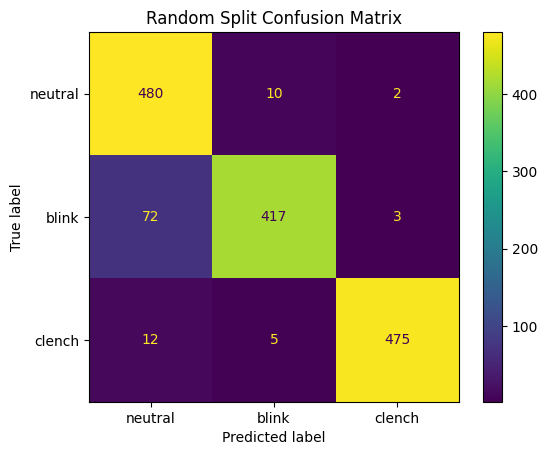

In [23]:
model_random, y_test_random, y_pred_random = evaluate_random_split(X, y)

In [24]:
#loso
def evaluate_loso(X, y, groups):
   
    unique_groups = np.unique(groups)
    if len(unique_groups) < 2:
        print("Not enough unique participant groups for LOSO.")
        return None, None

    logo = LeaveOneGroupOut()
    all_true = []
    all_pred = []

    for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        test_groups = np.unique(groups[test_idx])
        print(f"\nFold {fold} | Test group(s): {test_groups}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = make_svm_pipeline()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_acc = accuracy_score(y_test, y_pred)
        print("Fold accuracy:", fold_acc)

        all_true.extend(y_test.tolist())
        all_pred.extend(y_pred.tolist())

    all_true = np.asarray(all_true, dtype=int)
    all_pred = np.asarray(all_pred, dtype=int)

    print("\n=== LOSO Evaluation ===")
    print("Overall LOSO accuracy:", accuracy_score(all_true, all_pred))
    print(classification_report(all_true, all_pred, target_names=[LABEL_TO_NAME[i] for i in sorted(LABEL_TO_NAME)]))

    cm = confusion_matrix(all_true, all_pred, labels=sorted(LABEL_TO_NAME))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[LABEL_TO_NAME[i] for i in sorted(LABEL_TO_NAME)]
    )
    disp.plot()
    plt.title("LOSO Confusion Matrix")
    plt.show()

    return all_true, all_pred


Fold 1 | Test group(s): ['p1']
Fold accuracy: 0.6680894308943089

Fold 2 | Test group(s): ['p2']
Fold accuracy: 0.7760162601626016

=== LOSO Evaluation ===
Overall LOSO accuracy: 0.7040650406504065
              precision    recall  f1-score   support

     neutral       0.72      0.63      0.67      2460
       blink       0.83      0.54      0.65      2460
      clench       0.64      0.94      0.76      2460

    accuracy                           0.70      7380
   macro avg       0.73      0.70      0.70      7380
weighted avg       0.73      0.70      0.70      7380



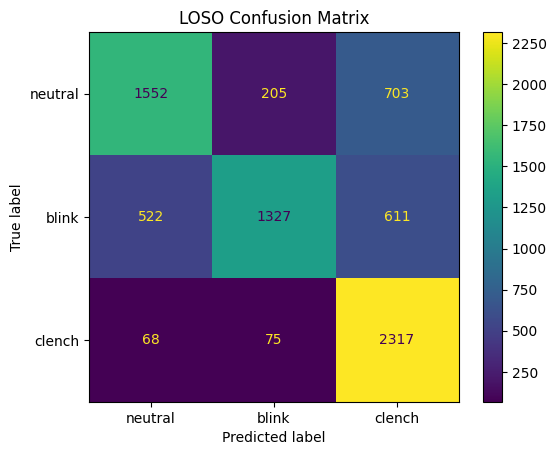

In [25]:
y_true_loso, y_pred_loso = evaluate_loso(X, y, groups)


=== Random Window Split Evaluation ===
Accuracy: 0.9359756097560976
              precision    recall  f1-score   support

     neutral       0.88      0.96      0.92       328
       blink       0.95      0.87      0.91       328
      clench       0.99      0.97      0.98       328

    accuracy                           0.94       984
   macro avg       0.94      0.94      0.94       984
weighted avg       0.94      0.94      0.94       984



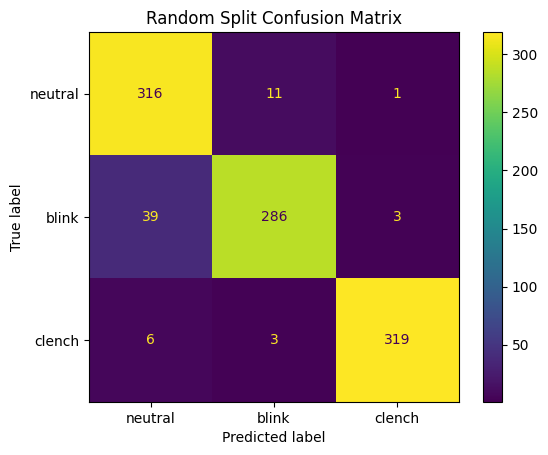


Fold 1 | Test group(s): ['p1']
Fold accuracy: 0.6642276422764227

Fold 2 | Test group(s): ['p2']
Fold accuracy: 0.7585365853658537

=== LOSO Evaluation ===
Overall LOSO accuracy: 0.7113821138211383
              precision    recall  f1-score   support

     neutral       0.75      0.67      0.71      1640
       blink       0.77      0.56      0.65      1640
      clench       0.66      0.90      0.76      1640

    accuracy                           0.71      4920
   macro avg       0.72      0.71      0.71      4920
weighted avg       0.72      0.71      0.71      4920



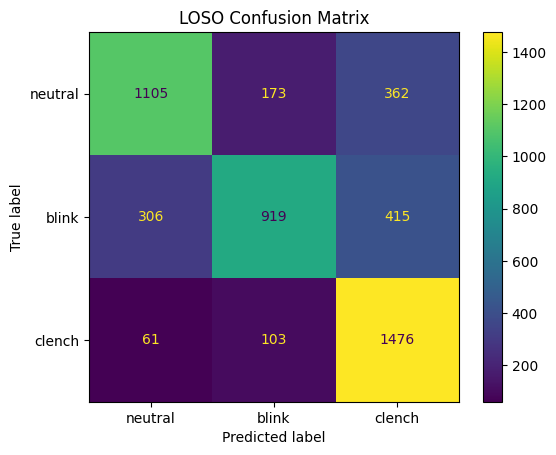

(array([2, 2, 2, ..., 1, 1, 1], shape=(4920,)),
 array([2, 2, 2, ..., 1, 1, 1], shape=(4920,)))

In [26]:
evaluate_random_split(X_bal, y_bal)
evaluate_loso(X_bal, y_bal, groups_bal)

In [27]:
#finales training auf ganzem dataset
final_model = make_svm_pipeline()
final_model.fit(X, y)

print("Final SVM model trained on full dataset.")

model_path = OUTPUT_DIR / "eeg_artifact_game_control.joblib"
joblib.dump(final_model, model_path)

print("Saved model to:", model_path)

Final SVM model trained on full dataset.
Saved model to: artifacts/eeg_artifact_game_control.joblib


In [28]:
#metadaten
metadata = {
    "model_type": "StandardScaler + SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')",
    "training_source": "XDF run recordings",
    "target_channels": TARGET_CHANNELS,
    "label_mapping": RUN_MARKER_TO_LABEL,
    "label_names": LABEL_TO_NAME,
    "segment_rule": "task marker (rest/blinking/teeth_clenching) to next pause",
    "bandpass_low": BANDPASS_LOW,
    "bandpass_high": BANDPASS_HIGH,
    "use_notch": USE_NOTCH,
    "notch_freq": NOTCH_FREQ,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_samples": int(len(y)),
    "n_features": int(X.shape[1]) if len(X.shape) == 2 else None,
    "n_groups": int(len(np.unique(groups))),
    "group_ids": sorted([str(g) for g in np.unique(groups)]),
    "files_used": sorted([Path(r["file_path"]).name for r in runs]),
}

metadata_path = OUTPUT_DIR / "svm_eeg_artifact_game_control_xdf_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata to:", metadata_path)
metadata

Saved metadata to: artifacts/svm_eeg_artifact_game_control_xdf_metadata.json


{'model_type': "StandardScaler + SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')",
 'training_source': 'XDF run recordings',
 'target_channels': ['F3', 'F4', 'C3', 'Cz', 'C4', 'P3', 'P4'],
 'label_mapping': {'rest': 0, 'blinking': 1, 'teeth_clenching': 2},
 'label_names': {0: 'neutral', 1: 'blink', 2: 'clench'},
 'segment_rule': 'task marker (rest/blinking/teeth_clenching) to next pause',
 'bandpass_low': 0.5,
 'bandpass_high': 100.0,
 'use_notch': True,
 'notch_freq': 50.0,
 'window_sec': 0.5,
 'step_sec': 0.1,
 'test_size': 0.2,
 'random_state': 42,
 'n_samples': 7380,
 'n_features': 169,
 'n_groups': 2,
 'group_ids': ['p1', 'p2'],
 'files_used': ['run1_p1.xdf', 'run1_p2.xdf', 'run2_p1.xdf']}